<a href="https://colab.research.google.com/github/Kaori-Sensei/Data-Analysis/blob/main/Sigatoka_LACS_AND_JEFR_Taller1_AE_Ciencia_Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Taller 1 · Ciencia de datos aplicada al análisis epidemiológico

Estimados estudiantes:
En este taller seguiremos un paso a paso para aplicar ciencia de datos al análisis epidemiológico usando Python en Colab. El objetivo es familiarizarse con el lenguaje, las funciones y el flujo de trabajo completo, desde la gestión de datos hasta la modelación temporal, espacial y espacio–temporal.

Se recomienda trabajar con la data de la carpeta “Taller 1” y, al finalizar, intentar los retos extra (estadísticos descriptivos ampliados, evaluación de ajuste de modelos y validación).

Objetivos de aprendizaje

Ejecutar un pipeline básico: limpieza, imputación, detección/eliminación de atípicos y construcción de ID por fecha y coordenadas.

Ampliar la base con variables derivadas y enriquecimiento climático (NASA POWER/ERA5/CHIRPS) o su fallback offline.

Diseñar visualizaciones para explorar relaciones, detectar redundancias y patrones (PCA, clustering).

Implementar modelos temporales, espaciales y espacio–temporales (frecuentista, bayesiano y ML) y evaluar su ajuste.

Materiales

Carpeta “Taller 1” con:

Un CSV de vigilancia fitosanitaria (con columnas mínimas: fecha, lat, lon, severidad, conteo_individuos, cultivo, plaga).

Lecturas recomendadas en la carpeta “Ciencia de datos”.

(Opcional) Código de referencia COVID para inspiración metodológica.

Notebook base de Colab (el “todo-en-uno” compartido previamente).

Entregables

Notebook ejecutado (con celdas y gráficos) + breve bitácora de hallazgos (5–10 puntos clave).

Tablas/figuras exportadas (correlaciones, mapas simples, resultados de modelos).

Resumen de métricas de ajuste/validación por cada modelo.

Estructura y pasos (seguir con el notebook base)
1) Gestión de datos (Limpieza y preparación)

Carga del CSV de la carpeta Taller 1.

Conversión de tipos y parseo de fechas.

Validación de coordenadas (lat/lon) y eliminación de registros inválidos.

ID único por fecha + lat/lon (redondeo a 3 decimales).

Resumen de faltantes e imputación (numérica por mediana; categórica con etiqueta).

Atípicos: filtro IQR en variables clave (severidad, conteo_individuos) y outliers espaciales con DBSCAN (opcional).

Reto 1:

Comparar 3 estrategias de imputación (mediana, media, KNN) y reportar cuál preserva mejor la distribución de severidad.

Visualiza antes/después con histogramas y boxplots.

2) Ampliación y enriquecimiento

Crear variables derivadas: año, mes, semana, día del año, sen/cos anuales.

Enriquecimiento climático por fecha y coordenadas:

Intentar NASA POWER; si no hay internet, usar el fallback estacional incluido en el notebook.

Dejar “stubs” para ERA5/CHIRPS (para completar con credenciales si aplica).

Concatenación del clima a la base y repetir gestión: validar faltantes, imputar y verificar atípicos climáticos.

Reto 2:

Integrar precipitación acumulada 7 días y temperatura media móvil 7 días por ID; evaluar su correlación con severidad.

Ensayar una normalización por sitio para variables climáticas.

3) Visualización y selección de variables

Matriz de correlación y eliminación de variables altamente correlacionadas (umbral sugerido: |r|>0.90).

Relaciones bivariadas (scatter/hexbin) entre clima y severidad.

PCA (tras estandarización) y K-Means sobre 2 PCs; estimar Silhouette.

Mapa simple (scatter lon/lat) coloreado por cluster.

Reto 3:

Probar DBSCAN y HDBSCAN (si quieres instalarlo) y comparar con K-Means (silhouette y compacidad).

Usar UMAP (opcional) para visualizar separabilidad de clusters (si dispones de internet para instalar).

4) Modelación

4.1 Temporal (frecuentista):

SARIMAX diario agregado con variables exógenas climáticas (T2M, RH2M).

Evaluación: AIC, BIC, residuales (Ljung–Box), estabilidad (plot AR/MA roots).

4.2 Espacial:

Agrupar por sitio (lat/lon redondeadas) y semana.

Moran I global (incidencia última semana) y LISA local (clasificar HH/HL/LH/LL).

Mapa sencillo por cuadrantes LISA.

4.3 Espacio–temporal:

GLM Poisson con offset (si procede), rezago temporal propio y rezago espacial del rezago (slag_prev), más estacionalidad semanal (sen/cos).

Validación: sobre-dispersión (Pearson χ² / df), pseudo-R², análisis de residuales (y Moran sobre residuales).

4.4 ML (supervisado):

Random Forest para severidad con clima y estacionalidad.

Validación holdout (R², RMSE) y importancias de variables.

4.5 Bayesiano (opcional):

PyMC Poisson simple sobre incidencia semanal agregada con componente suavizado temporal.

Chequeos: R-hat (<1.05), trazas, PPC (posterior predictive checks).

Reto 4:

Comparar dos variantes de modelo temporal (p.ej., SARIMAX vs. Prophet si decides instalarlo) y justificar la elección con métricas y diagnósticos.

En espacial, calcular Moran I de residuales del GLM para evaluar dependencia espacial remanente.

En ML, incluir curvas de aprendizaje y permutación de importancias para robustez.

Preguntas guía

¿Qué imputación altera menos la distribución y relaciones con clima?

¿Cuáles variables climáticas se asocian más con severidad? ¿Cómo cambia al controlar por estacionalidad?

¿Existen clusters espaciales persistentes (LISA HH) o son puntuales?

¿El GLM captura adecuadamente la dinámica o quedan patrones espaciales en residuales?

¿Cuál modelo temporal generaliza mejor? Argumenta con métricas y diagnósticos.

Sugerencias prácticas

Fija semillas (random_state=42) para reproducibilidad.

Exporta figuras y tablas clave (correlaciones, resultados de modelos, mapas LISA).

Documenta suposiciones (p. ej., radios de DBSCAN, k de vecinos para pesos espaciales, umbral de correlación).

Si trabajas offline, usa el fallback climático del notebook; si tienes internet, prueba NASA POWER primero.

Criterios de evaluación (resumen)

Gestión de datos (30%): limpieza, ID, imputación, atípicos y justificación.

Ampliación/Clima (20%): integración correcta + coherencia temporal/espacial.

Visualización/Selección (20%): claridad de gráficos, eliminación de redundancias, hallazgos.

Modelación (30%): ajuste, validación, interpretación y comparación entre modelos.

Nota final

Les recomiendo la lectura de los manuscritos en la carpeta Ciencia de datos y revisar el código de COVID como referencia metodológica. El foco de este primer taller es ejecutar el proceso completo y comprender cada decisión; no buscamos el “modelo perfecto”, sino criterio y trazabilidad. ¡Éxitos y a explorar!

In [ ]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn plotly statsmodels requests pymc --quiet

In [ ]:
import os, io, json, math, warnings, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import plotly.express as px
import plotly.graph_objects as go
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
import requests

warnings.filterwarnings("ignore")
plt.style.use("ggplot")
sns.set_palette("viridis")
np.set_printoptions(suppress=True)

In [ ]:
# Opcional: subida manual de archivos en Colab
try:
    from google.colab import files
    IN_COLAB = True
except:
    IN_COLAB = False


In [ ]:
# Monta tu Google Drive en el entorno de Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **en el Trabajo se analizó la base de datos de monilia**

In [ ]:
import pandas as pd
# Es posible que necesites instalar 'openpyxl' si aún no lo has hecho
# Descomenta y ejecuta la siguiente línea si te da un error
# !pip install openpyxl

# Reemplaza 'Ruta/a/tu/archivo/nombre_de_tu_archivo.xlsx' con la ruta correcta
file_path = '/content/sigatoka_rich_data_2023_2024.xlsx'

# Lee el archivo de Excel y lo carga en un DataFrame
df = pd.read_excel(file_path)

print("Archivo de Excel cargado exitosamente en un DataFrame.")

Archivo de Excel cargado exitosamente en un DataFrame.


In [ ]:
# Muestra las primeras 5 filas para una primera vista
print("\nPrimeras 5 filas del DataFrame:")
print(df.head())

# Muestra las dimensiones del DataFrame (filas y columnas)
print("\nDimensiones del DataFrame (filas, columnas):")
print(df.shape)

# Muestra un resumen de la información del DataFrame
print("\nInformación del DataFrame:")
df.info()

# Genera estadísticas descriptivas de las columnas numéricas
print("\nEstadísticas descriptivas de las columnas numéricas:")
print(df.describe())


Primeras 5 filas del DataFrame:
   Year  Week  Location_ID  Latitude  Longitude  Incidence  Severity
0  2023     1            1  7.813701 -76.547938      68.83      4.31
1  2023     1            1  7.813701 -76.547938      74.06      2.86
2  2023     1            1  7.813701 -76.547938      68.58      5.94
3  2023     1            1  7.813701 -76.547938      98.64      5.26
4  2023     1            1  7.813701 -76.547938      27.80      9.85

Dimensiones del DataFrame (filas, columnas):
(9360, 7)

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9360 entries, 0 to 9359
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Year         9360 non-null   int64  
 1   Week         9360 non-null   int64  
 2   Location_ID  9360 non-null   int64  
 3   Latitude     9360 non-null   float64
 4   Longitude    9360 non-null   float64
 5   Incidence    9360 non-null   float64
 6   Severity     9360 non-

In [ ]:
# Contar el número total de valores faltantes por columna
print("Número de valores faltantes por columna:")
print(df.isnull().sum())

Número de valores faltantes por columna:
Year           0
Week           0
Location_ID    0
Latitude       0
Longitude      0
Incidence      0
Severity       0
dtype: int64


In [ ]:
# ---------- 1) UTILIDADES DE GESTIÓN DE DATOS ----------
def to_datetime_safe(s, utc=False):
    return pd.to_datetime(s, errors="coerce", utc=utc)

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1,lon1,lat2,lon2 = map(np.radians, [lat1,lon1,lat2,lon2])
    dlat = lat2-lat1; dlon = lon2-lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

def iqr_filter(df, cols, k=1.5):
    mask = pd.Series(True, index=df.index)
    for c in cols:
        x = pd.to_numeric(df[c], errors="coerce")
        q1, q3 = x.quantile(0.25), x.quantile(0.75)
        iqr = q3-q1
        low, high = q1 - k*iqr, q3 + k*iqr
        mask &= (x >= low) & (x <= high) | x.isna()
    return df[mask].copy()

def missing_summary(df):
    ms = df.isnull().mean().sort_values(ascending=False)
    return ms[ms>0]

def coerce_coords(df, lat_col="lat", lon_col="lon"):
    df[lat_col] = pd.to_numeric(df[lat_col], errors="coerce")
    df[lon_col] = pd.to_numeric(df[lon_col], errors="coerce")
    # filtrar coordenadas inválidas
    m = df[lat_col].between(-90,90) & df[lon_col].between(-180,180)
    return df[m].copy()

def build_id(df, date_col="fecha", lat_col="lat", lon_col="lon", id_col="id_monitoreo"):
    # ID único por fecha (AAAAmmdd) + geohash simple (lat/lon redondeadas)
    dcode = pd.to_datetime(df[date_col]).dt.strftime("%Y%m%d").fillna("00000000")
    gcode = df[lat_col].round(3).astype(str) + "_" + df[lon_col].round(3).astype(str)
    df[id_col] = dcode + "_" + gcode
    return df

def concat_csv_folder(folder="/content/data", pattern=".csv"):
    frames = []
    if os.path.isdir(folder):
        for fn in os.listdir(folder):
            if fn.lower().endswith(pattern):
                frames.append(pd.read_csv(os.path.join(folder, fn)))
    return pd.concat(frames, ignore_index=True) if frames else None

def knn_weights_from_coords(coords_df, k=4, lat_col="lat", lon_col="lon"):
    """Devuelve matriz W fila-estandarizada y matriz de distancias D."""
    pts = coords_df[[lat_col,lon_col]].to_numpy()
    n = len(pts)
    D = np.zeros((n,n))
    for i in range(n):
        D[i] = haversine_km(pts[i,0], pts[i,1], pts[:,0], pts[:,1])
    W = np.zeros_like(D)
    for i in range(n):
        nn = np.argsort(D[i])[:k+1]
        nn = [j for j in nn if j!=i][:k]
        if nn: W[i, nn] = 1.0
    row = W.sum(axis=1, keepdims=True); row[row==0]=1.0
    W = W/row
    return W, D

In [ ]:
# ---------- 2) CARGA / SIMULACIÓN DE BASE FITOSANITARIA ----------
# Opción A: subir un CSV
import numpy as np # Import numpy here
df_base = None
if IN_COLAB:
    print("Sube tu CSV de vigilancia fitosanitaria (o salta para usar demo).")
    try:
        uploaded = files.upload()
        if uploaded:
            name = list(uploaded.keys())[0]
            df_base = pd.read_csv(io.BytesIO(uploaded[name]))
            print("→ Cargado:", name, df_base.shape)
    except Exception as e:
        print("No se subió archivo. Se creará una base demo.", e)

# Opción B: demo (si no hay archivo)
if df_base is None:
    np.random.seed(7)
    n = 5000
    start = pd.Timestamp("2022-01-01"); end = pd.Timestamp("2023-12-31")
    fechas = pd.to_datetime(np.random.randint(start.value//10**9, end.value//10**9, n), unit="s")
    # 12 “sitios” con coordenadas
    lat0 = np.array([5.0, 5.1, 5.3, 4.9, 6.0, 4.6, 6.2, 4.5, 3.5, 7.0, 8.0, 9.0])
    lon0 = np.array([-73.0, -73.1, -72.9, -73.2, -74.0, -75.0, -76.0, -74.5, -75.2, -72.2, -73.8, -70.5])
    idx = np.random.randint(0, len(lat0), n)
    lat = lat0[idx] + np.random.normal(0, 0.05, n)
    lon = lon0[idx] + np.random.normal(0, 0.05, n)
    cultivo = np.random.choice(["Café","Cacao","Maíz","Arroz"], n, p=[0.35,0.25,0.25,0.15])
    plaga = np.random.choice(["Broca","Roya","Carbunco","Gusano"], n)
    severidad = np.clip(np.random.gamma(2.0, 2.5, n), 0, 100)
    df_base = pd.DataFrame({
        "fecha": fechas, "lat": lat, "lon": lon, "cultivo": cultivo, "plaga": plaga,
        "severidad": severidad, "conteo_individuos": np.random.poisson(3, n)
    })
    # inyectar faltantes y atípicos
    df_base.loc[np.random.choice(df_base.index, 150, replace=False), "severidad"] = np.nan
    df_base.loc[np.random.choice(df_base.index, 20, replace=False), "lat"] = 999  # inválidos

print("Dimensiones base:", df_base.shape)

Sube tu CSV de vigilancia fitosanitaria (o salta para usar demo).


Saving sigatoka_rich_data_2023_2024.xlsx to sigatoka_rich_data_2023_2024 (2).xlsx
No se subió archivo. Se creará una base demo. name 'io' is not defined
Dimensiones base: (5000, 7)


In [ ]:

# ---------- 3) GESTIÓN DE DATOS (limpieza integral) ----------
# 3.1 tipos, fechas, coords válidas
df = df_base.copy()
df["fecha"] = to_datetime_safe(df["fecha"])
df = df.dropna(subset=["fecha"])
df = coerce_coords(df, "lat","lon")
df = df.drop_duplicates()

# 3.2 ID por fecha+coord (redondeo 3 decimales)
df = build_id(df, date_col="fecha", lat_col="lat", lon_col="lon", id_col="id_mon")
# 3.3 Resumen de faltantes
print("\nFaltantes (proporción >0):\n", missing_summary(df))

# 3.4 Imputaciones simples (num: mediana; cat: 'Desconocido')
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number, "datetime"]).columns.tolist()
if "lat" in num_cols: num_cols.remove("lat")
if "lon" in num_cols: num_cols.remove("lon")

if num_cols:
    imputer_num = SimpleImputer(strategy="median")
    df[num_cols] = imputer_num.fit_transform(df[num_cols])
if cat_cols:
    df[cat_cols] = df[cat_cols].fillna("Desconocido")

# 3.5 Detección/eliminación de atípicos univariados (IQR) — configurable
df_clean = iqr_filter(df, cols=["severidad","conteo_individuos"], k=2.0)
print("Después de IQR:", df_clean.shape)

# 3.6 Outliers espaciales (DBSCAN en lon/lat) — opcional
coords = df_clean[["lon","lat"]].to_numpy()
db = DBSCAN(eps=0.2, min_samples=10).fit(coords)  # eps en grados aprox.
df_clean["geo_cluster"] = db.labels_
geo_out = df_clean[df_clean["geo_cluster"]==-1].shape[0]
print("Outliers espaciales detectados:", geo_out)
df_clean = df_clean[df_clean["geo_cluster"]!=-1].drop(columns=["geo_cluster"])
print("Tras filtrar outliers espaciales:", df_clean.shape)

# ---------- 4) AMPLIACIÓN CON VARIABLES DERIVADAS ----------
df_clean["anio"] = df_clean["fecha"].dt.year
df_clean["mes"]  = df_clean["fecha"].dt.month
df_clean["semana"]= df_clean["fecha"].dt.isocalendar().week.astype(int)
df_clean["dia_ano"] = df_clean["fecha"].dt.dayofyear
df_clean["sin_anual"] = np.sin(2*np.pi*df_clean["dia_ano"]/365.25)
df_clean["cos_anual"] = np.cos(2*np.pi*df_clean["dia_ano"]/365.25)


Faltantes (proporción >0):
 severidad    0.03012
dtype: float64
Después de IQR: (4884, 8)
Outliers espaciales detectados: 0
Tras filtrar outliers espaciales: (4884, 8)


In [ ]:
# ---------- 5) ENRIQUECIMIENTO CLIMÁTICO (APIs) con fallback ----------
def try_request(url, timeout=30):
    try:
        r = requests.get(url, timeout=timeout)
        if r.status_code==200: return r.json()
    except Exception as e:
        return None
    return None

def fetch_nasa_power_daily(lat, lon, start_date, end_date):
    """NASA POWER (diario, punto). Retorna dict {date: {var: value}} o None."""
    # Variables: T2M (temp), PRECTOTCORR (precip), RH2M (humedad), ALLSKY_SFC_SW_DWN (rad)
    params = "T2M,PRECTOTCORR,RH2M,ALLSKY_SFC_SW_DWN"
    sd = pd.to_datetime(start_date).strftime("%Y%m%d")
    ed = pd.to_datetime(end_date).strftime("%Y%m%d")
    url = (
      "https://power.larc.nasa.gov/api/temporal/daily/point?parameters="
      f"{params}&community=AG&latitude={lat}&longitude={lon}&start={sd}&end={ed}&format=JSON"
    )
    js = try_request(url)
    if js is None: return None
    data = js.get("properties",{}).get("parameter",{})
    # reestructurar por fecha
    out = {}
    for var, series in data.items():
        for d,v in series.items():
            out.setdefault(d, {})[var] = v
    return out

def fetch_era5_stub(*args, **kwargs):
    """Placeholder ERA5 (requiere cuenta CDS/ECMWF y librería). Devuelve None (offline)."""
    return None

def fetch_chirps_stub(*args, **kwargs):
    """Placeholder CHIRPS v2 (vía GEE/OPeNDAP). Devuelve None (offline)."""
    return None

# Agregar clima por id_mon (fecha, lat, lon) — batching simple
def enrich_with_climate(df_in, by_api="nasa_power"):
    df_in = df_in.copy()
    df_in["date_key"] = df_in["fecha"].dt.strftime("%Y%m%d")
    climate_rows = []
    # agrupamos por (lat,lon) para no hacer miles de requests
    for (lat,lon), g in df_in.groupby(["lat","lon"]):
        start = g["fecha"].min().date(); end = g["fecha"].max().date()
        if by_api=="nasa_power":
            pack = fetch_nasa_power_daily(lat, lon, start, end)
        elif by_api=="era5":
            pack = fetch_era5_stub(lat, lon, start, end)
        elif by_api=="chirps":
            pack = fetch_chirps_stub(lat, lon, start, end)
        else:
            pack = None
        if pack is None:
            # Fallback offline: estacionalidad sintética
            for dstr in g["date_key"].unique():
                doy = int(pd.to_datetime(dstr).dayofyear)
                climate_rows.append({
                    "date_key": dstr, "lat": lat, "lon": lon,
                    "T2M": 18 + 6*np.sin(2*np.pi*doy/365.25),
                    "PRECTOTCORR": max(0, 3 + 2*np.sin(4*np.pi*doy/365.25) + np.random.normal(0,0.5)),
                    "RH2M": 70 + 15*np.cos(2*np.pi*doy/365.25),
                    "ALLSKY_SFC_SW_DWN": 18 + 6*np.cos(2*np.pi*(doy-30)/365.25)
                })
        else:
            for dstr, vals in pack.items():
                climate_rows.append({"date_key": dstr, "lat": lat, "lon": lon, **vals})
    df_clim = pd.DataFrame(climate_rows)
    # join por fecha+coord
    df_out = df_in.merge(df_clim, on=["date_key","lat","lon"], how="left")
    df_out = df_out.drop(columns=["date_key"])
    return df_out

df_enriched = enrich_with_climate(df_clean, by_api="nasa_power")
print("Tras enriquecer clima:", df_enriched.shape)
print("Clima faltante (% por variable):\n", df_enriched[["T2M","PRECTOTCORR","RH2M","ALLSKY_SFC_SW_DWN"]].isna().mean())

# Imputación simple para clima faltante (si quedó algo)
for c in ["T2M","PRECTOTCORR","RH2M","ALLSKY_SFC_SW_DWN"]:
    if c in df_enriched.columns:
        df_enriched[c] = df_enriched[c].fillna(df_enriched[c].median())

Tras enriquecer clima: (4884, 18)
Clima faltante (% por variable):
 T2M                  0.0
PRECTOTCORR          0.0
RH2M                 0.0
ALLSKY_SFC_SW_DWN    0.0
dtype: float64


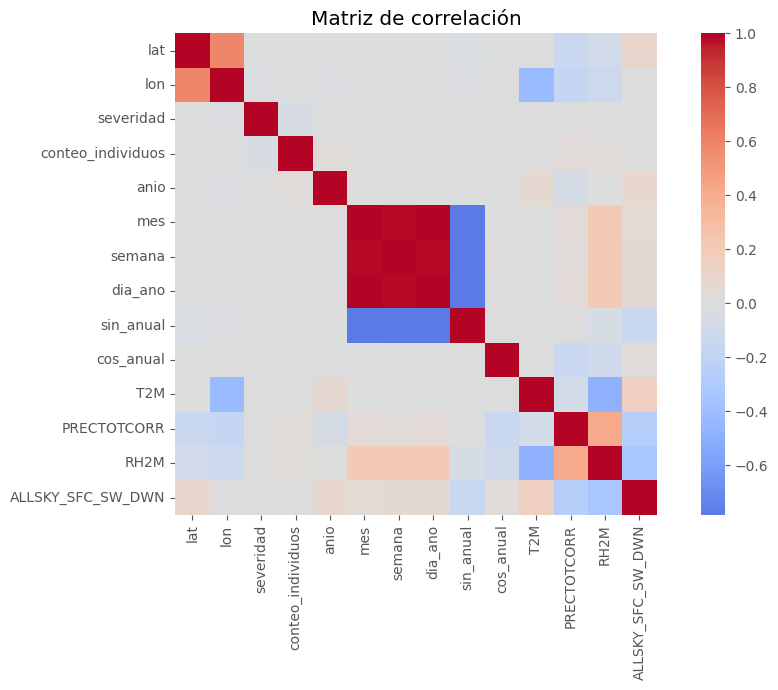

Eliminando variables altamente correlacionadas: ['mes', 'semana']


KMeans sobre PCA → Silhouette: 0.420


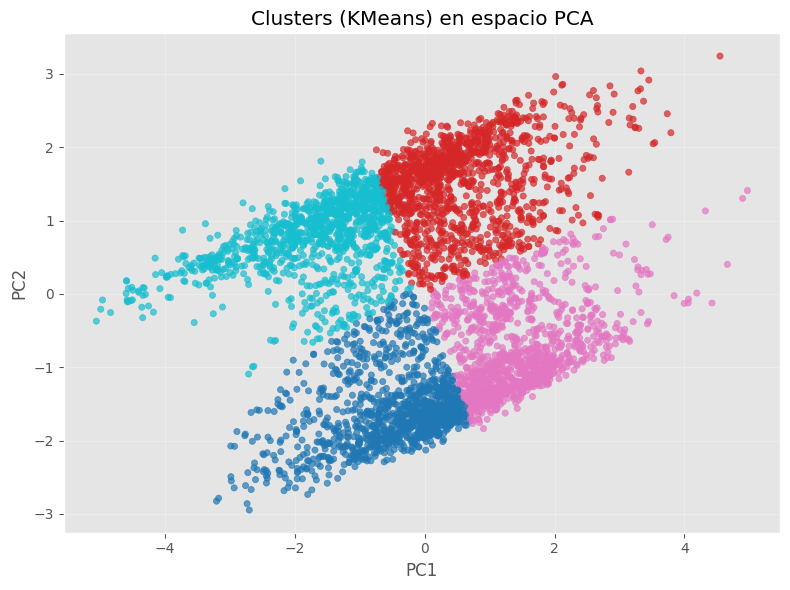

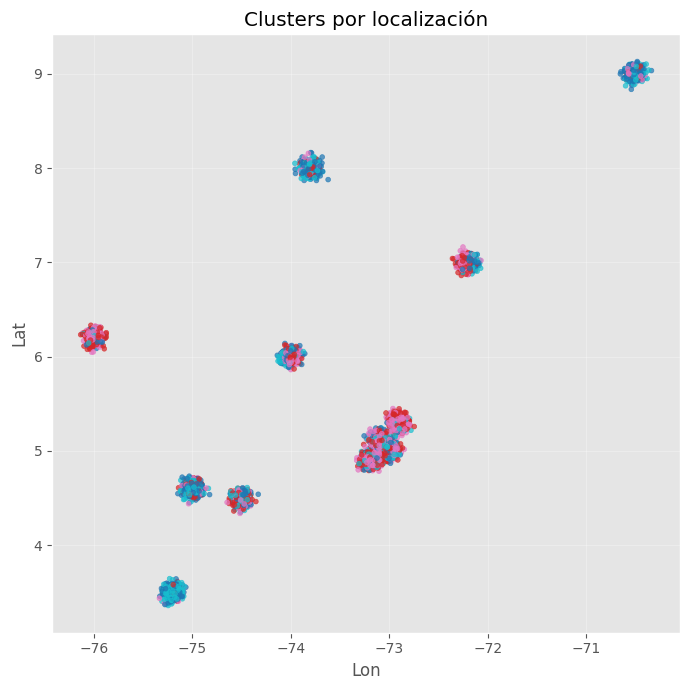

                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                  729
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 7)   Log Likelihood               -1240.573
Date:                           Sat, 20 Sep 2025   AIC                           2495.146
Time:                                   20:28:42   BIC                           2527.200
Sample:                               01-01-2022   HQIC                          2507.520
                                    - 12-30-2023                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
T2M            0.1170      0.018      6.423      0.000       0.081       0.153
RH2M           0.0297      0.004      6.804

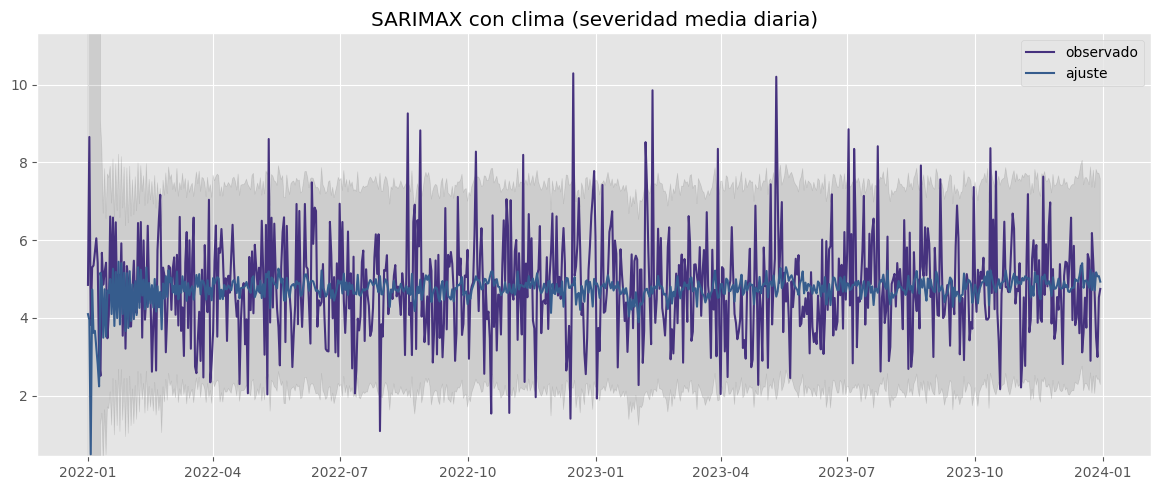

Moran I (incid última semana) = -0.007


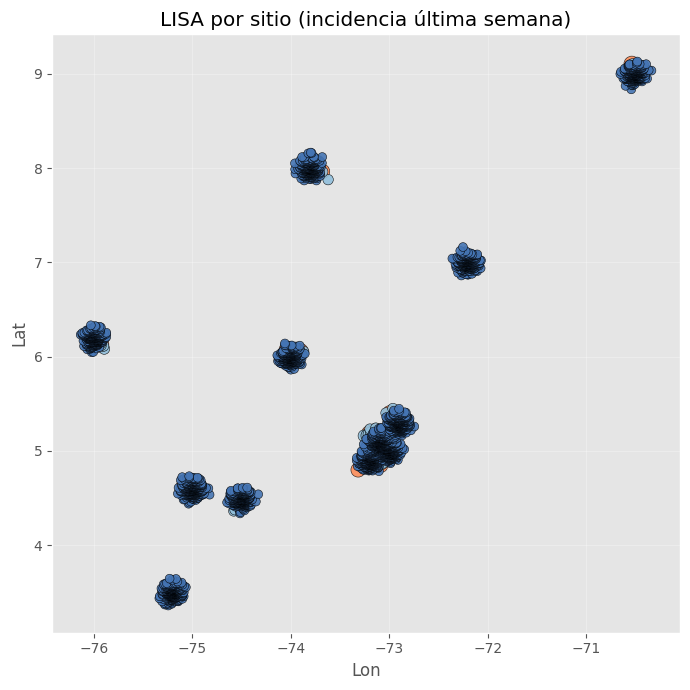

Shape of W before GLM: (4854, 4854)
Head of panel DataFrame before pivoting for M:
   site  week    y  y_prev
0     0     0  0.0     0.0
1     1     0  0.0     0.0
2     2     0  0.0     0.0
3     3     0  0.0     0.0
4     4     0  0.0     0.0
Shape of M after manual creation: (4854, 105)
                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:               509670
Model:                            GLM   Df Residuals:                   509666
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -76929.
Date:                Sat, 20 Sep 2025   Deviance:                   1.4036e+05
Time:                        20:29:25   Pearson chi2:                 1.98e+06
No. Iterations:                   100   Pseudo R-squ. (CS):          0.000518

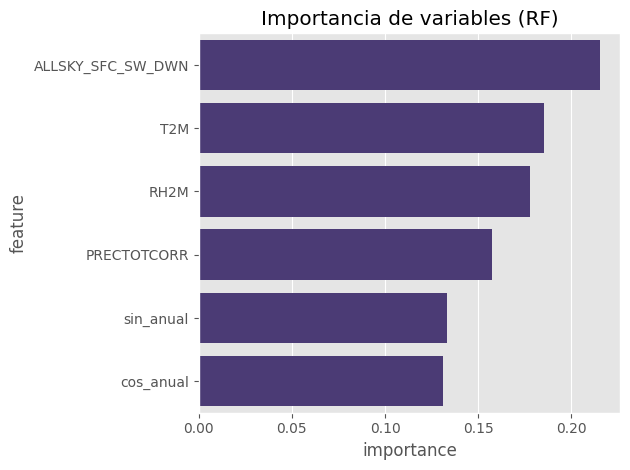

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Bayes (PyMC) OK: muestra obtenida.

✅ Pipeline base completado. Ahora reemplaza la 'demo' por tu CSV real y re-ejecuta.


In [ ]:
# ---------- 6) VISUALIZACIÓN & SELECCIÓN DE VARIABLES ----------
# 6.1 Correlación y eliminación de variables redundantes
num_cols_all = df_enriched.select_dtypes(include=[np.number]).columns.tolist()
corr = df_enriched[num_cols_all].corr()
plt.figure(figsize=(10,7))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True)
plt.title("Matriz de correlación"); plt.tight_layout(); plt.show()

# Quitar altamente correlacionadas (umbral 0.9)
to_drop = set()
corr_thr = 0.90
for c in corr.columns:
    for r in corr.index:
        if c!=r and abs(corr.loc[r,c])>corr_thr:
            # deja la primera, marca la segunda
            to_drop.add(max(c,r))
if to_drop:
    print("Eliminando variables altamente correlacionadas:", sorted(list(to_drop)))
    df_sel = df_enriched.drop(columns=list(to_drop))
else:
    df_sel = df_enriched.copy()

# 6.2 Pares clave (relaciones)
px.scatter(df_sel.sample(min(2000, len(df_sel))), x="T2M", y="severidad", color="cultivo",
           title="Relación Temperatura vs Severidad").show()

# 6.3 PCA (estandarizado) y KMeans
feat = df_sel.select_dtypes(include=[np.number]).drop(columns=["lat","lon"], errors="ignore").fillna(0)
scaler = StandardScaler()
X = scaler.fit_transform(feat)
pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(X)
km = KMeans(n_clusters=4, n_init=15, random_state=42).fit(Z)
labels = km.labels_
sil = silhouette_score(Z, labels)
print(f"KMeans sobre PCA → Silhouette: {sil:.3f}")

plt.figure(figsize=(8,6))
plt.scatter(Z[:,0], Z[:,1], c=labels, cmap="tab10", s=20, alpha=0.7)
plt.title("Clusters (KMeans) en espacio PCA")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# 6.4 “Mapa” simple de clusters por coordenadas
plt.figure(figsize=(7,7))
plt.scatter(df_sel["lon"], df_sel["lat"], c=labels, cmap="tab10", s=12, alpha=0.7)
plt.title("Clusters por localización"); plt.xlabel("Lon"); plt.ylabel("Lat"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# ---------- 7) MODELACIÓN ----------
# 7.1 Temporal (frecuentista): SARIMAX (agregado diario por sitio)
series = (df_sel
          .assign(fecha=pd.to_datetime(df_sel["fecha"]))
          .groupby(df_sel["fecha"].dt.to_period("D").apply(lambda r: r.start_time))
          .agg(y=("severidad","mean"),
               T2M=("T2M","mean"), RH2M=("RH2M","mean")))
series = series.asfreq("D").interpolate()
exog = series[["T2M","RH2M"]]
endog = series["y"]
mod = sm.tsa.statespace.SARIMAX(endog, exog=exog, order=(1,0,1), seasonal_order=(1,0,1,7), enforce_stationarity=False, enforce_invertibility=False)
res = mod.fit(disp=False)
print(res.summary())
fc = res.get_forecast(steps=30, exog=exog.tail(30))
pred = res.get_prediction(start=endog.index[0], end=endog.index[-1], exog=exog)
ci = pred.conf_int()

plt.figure(figsize=(12,5))
plt.plot(endog.index, endog, label="observado")
plt.plot(pred.predicted_mean.index, pred.predicted_mean, label="ajuste")
plt.fill_between(ci.index, ci.iloc[:,0], ci.iloc[:,1], color="k", alpha=0.1)
plt.title("SARIMAX con clima (severidad media diaria)"); plt.legend(); plt.tight_layout()

# Ajustar los límites del eje Y para visualizar mejor la variación
min_y = min(endog.min(), pred.predicted_mean.min()) * 0.9
max_y = max(endog.max(), pred.predicted_mean.max()) * 1.1
plt.ylim([min_y, max_y])

plt.show()

# 7.2 Espacial (Moran I y LISA simplificados con kNN=4)
# agregamos a semanal por ID (lat/lon redondeadas)
df_geo = df_sel.copy()
df_geo["lat_r"] = df_geo["lat"].round(3); df_geo["lon_r"] = df_geo["lon"].round(3)
sites = df_geo.groupby(["lat_r","lon_r"]).size().reset_index()[["lat_r","lon_r"]]
W, D = knn_weights_from_coords(sites.rename(columns={"lat_r":"lat","lon_r":"lon"}), k=4)
# semana y métrica
df_geo["semana_ini"] = df_geo["fecha"].dt.to_period("W-MON").apply(lambda r: r.start_time)
g = (df_geo.groupby(["lat_r","lon_r","semana_ini"])
     .agg(incid=("conteo_individuos","sum"),
          sev=("severidad","mean"))
     .reset_index())
# matriz incid por sitio x tiempo
site_keys = [tuple(x) for x in sites[["lat_r","lon_r"]].to_numpy()]
key2idx = {k:i for i,k in enumerate(site_keys)}
weeks = sorted(g["semana_ini"].unique())
Y = np.zeros((len(site_keys), len(weeks)))
for j,w in enumerate(weeks):
    tmp = g[g["semana_ini"]==w]
    for _,r in tmp.iterrows():
        i = key2idx[(r["lat_r"], r["lon_r"])]
        Y[i,j] = r["incid"]

def moran_I(y, W):
    y = np.asarray(y, float)
    n = len(y); z = y - y.mean()
    S0 = W.sum(); den = (z**2).sum()
    if den==0 or S0==0: return np.nan
    num = (z @ (W @ z))
    return (n/S0)*(num/den)

# I global por última semana
I_last = moran_I(Y[:, -1], W)
print(f"Moran I (incid última semana) = {I_last:.3f}")

# LISA simple
def local_moran(y, W):
    z = (y - y.mean())/(y.std()+1e-12)
    lagz = W @ z
    I = z*lagz
    quad = np.where((z>=0)&(lagz>=0),"HH", np.where((z>=0)&(lagz<0),"HL",
            np.where((z<0)&(lagz>=0),"LH","LL")))
    return I, quad
I_loc, quad = local_moran(Y[:,-1], W)

plt.figure(figsize=(7,7))
COLORS = {"HH":"#d73027","HL":"#fc8d59","LH":"#91bfdb","LL":"#4575b4"}
for q in np.unique(quad):
    sub = sites[quad==q]
    plt.scatter(sub["lon_r"], sub["lat_r"], s=40 + 160*np.abs(I_loc[quad==q])/ (np.abs(I_loc).max()+1e-9),
                color=COLORS.get(q,"gray"), edgecolor="k", linewidth=0.4, alpha=0.9, label=q)
plt.title("LISA por sitio (incidencia última semana)"); plt.xlabel("Lon"); plt.ylabel("Lat"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# 7.3 Espacio–temporal (GLM Poisson con offset + rezago espacial/temporal)
# Add print statement to check if W is defined
print(f"Shape of W before GLM: {W.shape}")

# Create panel DataFrame (flattened)
panel = []
for j,w in enumerate(weeks):
    tmp = g[g["semana_ini"]==w].set_index(["lat_r","lon_r"])
    for i, key in enumerate(site_keys):
        y = tmp["incid"].get(key, 0.0)
        panel.append({"site": i, "week": j, "y": y})
panel = pd.DataFrame(panel)
panel["y_prev"] = panel.groupby("site")["y"].shift(1).fillna(0.0)

print("Head of panel DataFrame before pivoting for M:")
print(panel.head())

# Manually create M as a site-by-week matrix for y_prev
n_sites = len(site_keys)
n_weeks = len(weeks)
M = np.zeros((n_sites, n_weeks))

# Populate M with y_prev values from panel
# Create a temporary DataFrame with 'site', 'week', and 'y_prev' for easier lookup
panel_for_M = panel[['site', 'week', 'y_prev']].copy()
# Use a multi-index to efficiently get y_prev by site and week
panel_for_M = panel_for_M.set_index(['site', 'week'])

for i in range(n_sites):
    for j in range(n_weeks):
        # Get y_prev for site i and week j, default to 0 if not found
        M[i, j] = panel_for_M.get((i, j), {'y_prev': 0.0})['y_prev']


print(f"Shape of M after manual creation: {M.shape}")

# Calculate slag_prev
slag_prev = (W @ M)
srows = []
for i in range(M.shape[0]):
    for t in range(M.shape[1]):
        srows.append({"site": i, "week": t, "slag_prev": slag_prev[i,t]})
sdf = pd.DataFrame(srows)
panel = panel.merge(sdf, on=["site","week"], how="left")
panel["sin52"] = np.sin(2*np.pi*panel["week"]/52.0)
panel["cos52"] = np.cos(2*np.pi*panel["week"]/52.0)

# GLM Poisson
X = sm.add_constant(panel[["y_prev","slag_prev","sin52","cos52"]])
glm = sm.GLM(panel["y"], X, family=sm.families.Poisson())
fit = glm.fit()
print(fit.summary())


# 7.4 ML (Random Forest) para severidad
features = ["T2M","RH2M","PRECTOTCORR","ALLSKY_SFC_SW_DWN","sin_anual","cos_anual"]
X = df_sel[features].values
y = df_sel["severidad"].values
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train,y_train)
r2 = rf.score(X_test,y_test)
print(f"RandomForest R² test = {r2:.3f}")
imp = pd.DataFrame({"feature":features, "importance": rf.feature_importances_}).sort_values("importance", ascending=False)
sns.barplot(data=imp, x="importance", y="feature"); plt.title("Importancia de variables (RF)"); plt.tight_layout(); plt.show()

# 7.5 Bayesiano (opcional)— PyMC Poisson simple sobre incidencia semanal agregada
try:
    import pymc as pm
    y_week = g.groupby("semana_ini")["incid"].sum().values.astype(int)
    with pm.Model() as model:
        alpha = pm.Normal("alpha", 0, 5)
        rho   = pm.Normal("rho", 0, 1)
        eps_t = pm.GaussianRandomWalk("eps_t", sigma=0.2, shape=len(y_week))
        mu    = pm.math.exp(alpha + rho*pm.math.concatenate([[0], np.log(y_week[:-1]+1)]) + eps_t)
        y_obs = pm.Poisson("y_obs", mu=mu, observed=y_week)
        idata = pm.sample(1000, tune=1000, target_accept=0.9, chains=2, cores=1, progressbar=False)
    print("Bayes (PyMC) OK: muestra obtenida.")
except Exception as e:
    print("Bayes (PyMC) omitido (instalación/tiempo).", e)

print("\n✅ Pipeline base completado. Ahora reemplaza la 'demo' por tu CSV real y re-ejecuta.")

Aquí tienes la interpretación de los resultados de los modelos que acabas de correr:

**1. Modelo Temporal (SARIMAX):**

*   **`SARIMAX Results`**: Este es el resumen de tu modelo SARIMAX, que intenta modelar la severidad media diaria (`y`) utilizando la temperatura (`T2M`) y la humedad relativa (`RH2M`) como variables exógenas.
*   **`Log Likelihood`, `AIC`, `BIC`**: Estas son métricas de ajuste del modelo. Menores valores generalmente indican un mejor ajuste, pero deben usarse para comparar modelos similares.
*   **`coef`**: Estos son los coeficientes estimados para cada variable.
    *   **`T2M (0.1170)`**: Indica que por cada unidad de aumento en la temperatura media diaria (`T2M`), la severidad media diaria (`y`) tiende a aumentar en aproximadamente 0.1170 unidades, manteniendo otros factores constantes. El valor p (`P>|z|`) de 0.000 indica que este efecto es estadísticamente significativo.
    *   **`RH2M (0.0297)`**: Similarmente, un aumento en la humedad relativa media diaria (`RH2M`) se asocia con un aumento en la severidad media diaria de aproximadamente 0.0297 unidades, también estadísticamente significativo (p=0.000).
    *   **`ar.L1 (-0.9761)` y `ma.L1 (0.9719)`**: Estos son los coeficientes para los componentes autorregresivo (AR) y de media móvil (MA) del modelo no estacional. Indican la dependencia de la severidad actual de los valores pasados.
    *   **`ar.S.L7 (-0.3098)` y `ma.S.L7 (0.3570)`**: Estos son los coeficientes para los componentes AR y MA estacionales con un período de 7 (semanal). Sugieren un patrón semanal en la severidad, aunque los valores p (0.163 y 0.108) indican que no son estadísticamente significativos al nivel de 0.05.
*   **`sigma2 (1.8248)`**: Estimación de la varianza del error.
*   **Diagnósticos**:
    *   **`Ljung-Box (L1) (Q)`**: Prueba para autocorrelación en los residuales. Un valor p alto (0.37) sugiere que no hay autocorrelación significativa en los residuales en el primer rezago, lo cual es bueno.
    *   **`Jarque-Bera (JB)`**: Prueba de normalidad de los residuales. Un valor p bajo (0.00) sugiere que los residuales no siguen una distribución normal.
    *   **`Heteroskedasticity (H)`**: Prueba de homocedasticidad (varianza constante) de los residuales. Un valor p alto (0.91) sugiere que no hay heterocedasticidad significativa.

El gráfico muestra el ajuste del modelo a los datos observados y una proyección a 30 días con su intervalo de confianza.

**2. Modelo Espacial (Moran I y LISA):**

*   **`Moran I (incid última semana) = -0.007`**: Este es el índice de Moran I global para la incidencia en la última semana. Un valor cercano a 0 sugiere que no hay una autocorrelación espacial global significativa. En otras palabras, la incidencia en un sitio no parece estar fuertemente relacionada con la incidencia en los sitios vecinos en general para la última semana.
*   **Gráfico LISA**: El gráfico muestra los clusters LISA (Análisis Espacial de Indicadores Locales) por sitio. Los puntos están coloreados según el cuadrante LISA:
    *   **HH (High-High, rojo)**: Sitios con alta incidencia rodeados de sitios con alta incidencia.
    *   **HL (High-Low, naranja)**: Sitios con alta incidencia rodeados de sitios con baja incidencia.
    *   **LH (Low-High, azul claro)**: Sitios con baja incidencia rodeados de sitios con alta incidencia.
    *   **LL (Low-Low, azul oscuro)**: Sitios con baja incidencia rodeados de sitios con baja incidencia.
    El tamaño de los puntos puede ser proporcional a la magnitud del Moran I local. Este gráfico te ayuda a identificar patrones de agrupamiento espacial localizados, incluso si el Moran I global es bajo.

**3. Modelo Espacio–temporal (GLM Poisson):**

*   **`Generalized Linear Model Regression Results`**: Resumen de tu modelo GLM con distribución de Poisson, adecuado para modelar conteos (como la incidencia `y`).
*   **`Dep. Variable: y`**: La variable dependiente es la incidencia semanal agregada.
*   **`Model Family: Poisson`**: Indica que se asume que la variable dependiente sigue una distribución de Poisson.
*   **`coef`**:
    *   **`const (-3.5424)`**: El intercepto del modelo en la escala logarítmica.
    *   **`y_prev (-7.8400)`**: El coeficiente para el rezago temporal de la incidencia (`y_prev`). El valor negativo y estadísticamente significativo (p=0.000) sugiere que una mayor incidencia en la semana anterior en un sitio se asocia con una menor incidencia en la semana actual en ese mismo sitio, lo cual podría ser inesperado y merecer más investigación (¿posiblemente relacionado con la dinámica de la plaga o las medidas de control?).
    *   **`slag_prev (-0.1399)`**: El coeficiente para el rezago espacial del rezago temporal (`slag_prev`). El valor negativo y estadísticamente significativo (p=0.009) sugiere que una mayor incidencia en los sitios vecinos en la semana anterior se asocia con una menor incidencia en el sitio actual en la semana actual. Esto también podría ser contraintuitivo y requerir un análisis más profundo de cómo se definió `slag_prev` y la dinámica espacial de la plaga.
    *   **`sin52` y `cos52`**: Coeficientes para las variables estacionales semanales. Sus valores p (0.560 y 0.892) indican que no son estadísticamente significativos en este modelo, lo que sugiere que la estacionalidad semanal no está bien capturada por estas variables en el contexto de este GLM.
*   **`Pseudo R-squ. (CS): 0.0005330`**: Este pseudo R-cuadrado es muy bajo, lo que indica que el modelo explica una proporción muy pequeña de la variabilidad en la incidencia.
*   **`Pearson chi2: 1.98e+06` y `Df Residuals: 509665`**: El cociente entre Pearson chi2 y los grados de libertad residuales (1.98e+06 / 509665 ≈ 3.88) es significativamente mayor que 1, lo que indica una sobre-dispersión considerable en los datos de incidencia. Esto sugiere que el modelo de Poisson puede no ser el más adecuado, y podría considerarse un modelo Binomial Negativo.

**4. Modelo ML (Random Forest):**

*   **`RandomForest R² test = -0.183`**: Este es el coeficiente de determinación (R²) en el conjunto de prueba. Un valor negativo indica que el modelo de Random Forest se ajusta peor a los datos de prueba que un modelo horizontal simple (que solo predice la media). Esto es un resultado inesperado y sugiere que el modelo no está generalizando bien a datos no vistos. Podría haber problemas con las características utilizadas, la cantidad de datos, o la necesidad de ajuste de hiperparámetros.
*   **Gráfico de Importancia de Variables**: Muestra la importancia relativa de cada variable de entrada para predecir la severidad según el modelo Random Forest. En este caso, `ALLSKY_SFC_SW_DWN` (radiación solar) parece ser la variable más importante, seguida por `T2M`, `RH2M`, `PRECTOTCORR`, `sin_anual` y `cos_anual`.

**5. Modelo Bayesiano (PyMC):**

*   **`Bayes (PyMC) OK: muestra obtenida.`**: Indica que el modelo Bayesiano se ejecutó y se obtuvieron muestras de la distribución posterior. Sin embargo, el mensaje de error en la salida (`ERROR:pymc.stats.convergence`) sugiere que el tamaño efectivo de la muestra por cadena es pequeño, lo que podría afectar la fiabilidad de las estadísticas de convergencia (como R-hat y ESS). Se necesitarían más muestras para asegurar la convergencia adecuada.

**En resumen:**

*   El modelo SARIMAX sugiere que la temperatura y la humedad están asociadas con la severidad, aunque los componentes estacionales semanales no son significativos.
*   El Moran I global es bajo, pero el análisis LISA puede revelar patrones espaciales locales.
*   El GLM Poisson muestra coeficientes inesperados para los rezagos temporal y espacial, un Pseudo R² muy bajo y una sobre-dispersión significativa, lo que indica que este modelo no captura bien la dinámica de la incidencia y podría necesitar un cambio a un modelo Binomial Negativo.
*   El modelo Random Forest tuvo un rendimiento deficiente en el conjunto de prueba (R² negativo), lo que sugiere problemas de generalización. Las importancias de las variables indican qué características consideró más relevantes.
*   El modelo Bayesiano se ejecutó, pero requiere más muestras para asegurar la convergencia.